# Analisis Penentuan Jumlah Cluster Optimal pada K-Means Clustering
## Data Fitur Kualitas Udara (CO, NO2, SO2) — Hasil Ekstraksi TSFEL (68 Fitur)

**Tujuan notebook ini:**


## 1. Konsep Dasar

### 1.1 Principal Component Analysis (PCA)
PCA adalah teknik reduksi dimensi yang mentransformasi fitur-fitur asli (yang mungkin saling berkorelasi) menjadi sekumpulan variabel baru yang disebut **komponen utama (principal components)**, yang **tidak saling berkorelasi** dan diurutkan berdasarkan seberapa besar variansi data yang mereka jelaskan.

Secara matematis, PCA mencari vektor eigen dari matriks kovarians data terstandarisasi $\Sigma$:

$$\Sigma v_i = \lambda_i v_i$$

di mana $v_i$ adalah komponen utama ke-$i$ dan $\lambda_i$ adalah variansi yang dijelaskan oleh komponen tersebut. Komponen dengan $\lambda_i$ terbesar dipilih lebih dulu karena menjelaskan variansi data paling banyak.

**Kenapa perlu standardisasi sebelum PCA?** Karena fitur-fitur TSFEL memiliki skala yang sangat berbeda (misalnya `abs_energy` bisa bernilai jutaan sedangkan `entropy` bernilai < 2). Tanpa standardisasi, PCA akan didominasi oleh fitur berskala besar saja.

### 1.2 K-Means Clustering
K-Means mengelompokkan data ke dalam $k$ cluster dengan meminimalkan total jarak kuadrat titik ke centroid clusternya (disebut **inertia** atau **WCSS – Within Cluster Sum of Squares**):

$$J = \sum_{j=1}^{k} \sum_{x_i \in C_j} \lVert x_i - \mu_j \rVert^2$$

### 1.3 Menentukan Jumlah Cluster (k) Terbaik
Dua metode yang dipakai di notebook ini:

- **Elbow Method**: memplot nilai inertia terhadap $k$. Titik "siku" (elbow) — di mana penurunan inertia mulai melandai — mengindikasikan $k$ yang cukup baik. Metode ini bersifat visual/subjektif.
- **Silhouette Score**: mengukur seberapa mirip suatu titik dengan clusternya sendiri dibanding cluster terdekat lainnya, untuk setiap titik $i$:

$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$

  dengan $a(i)$ = rata-rata jarak $i$ ke titik lain dalam cluster yang sama, dan $b(i)$ = rata-rata jarak $i$ ke titik-titik di cluster terdekat lainnya. Nilai berkisar $[-1, 1]$; semakin mendekati 1 semakin baik. $k$ terbaik dipilih dari **silhouette score rata-rata tertinggi** (metode ini lebih objektif dibanding elbow, sehingga dipakai sebagai penentu utama $k$ terbaik pada notebook ini).

### 1.4 Hopkins Statistic — Seberapa Baik Data Bisa Di-cluster?
Sebelum bicara "berapa cluster terbaik", pertanyaan yang lebih mendasar adalah: **apakah data ini punya struktur cluster sama sekali, atau sebarannya acak/seragam (uniform)?** Hopkins Statistic menjawab ini dengan membandingkan:
- jarak titik-titik *asli* data ke tetangga terdekatnya ($u_i$), vs
- jarak titik-titik *acak buatan* (uniform random) dalam ruang yang sama ke tetangga terdekat di data asli ($w_i$)

$$H = \frac{\sum w_i}{\sum u_i + \sum w_i}$$

**Interpretasi:** $H \approx 0.5$ → data cenderung acak/seragam (tidak ada struktur cluster). $H$ mendekati **1** → data punya kecenderungan cluster yang kuat. $H$ mendekati **0** → data cenderung teratur/grid-like (jarang terjadi pada data nyata).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.dpi"] = 110
np.random.seed(42)

FILES = {
    "CO":  "Data_Polutan_Sekelas/ekstraksi_fitur_co.csv",
    "NO2": "Data_Polutan_Sekelas/ekstraksi_fitur_no2.csv",
    "SO2": "Data_Polutan_Sekelas/ekstraksi_fitur_so2.csv",
}


## 2. Memuat & Memeriksa Data

Setiap file berisi kolom identitas (`id`, `nama`, `daerah`) diikuti 68 kolom fitur numerik hasil ekstraksi TSFEL. Kita periksa dulu ukuran datanya, nilai kosong (NaN), dan fitur yang variansinya nol (fitur konstan — tidak berguna untuk PCA/clustering karena tidak membedakan satu data dengan yang lain, dan bisa membuat proses standardisasi menjadi tidak stabil / dibagi nol).

In [2]:
raw = {}
for name, path in FILES.items():
    df = pd.read_csv(path)
    raw[name] = df
    print(f"--- {name} ---")
    print(f"  Jumlah baris (sampel/lokasi) : {df.shape[0]}")
    print(f"  Jumlah kolom fitur           : {df.shape[1] - 3}  (di luar id, nama, daerah)")
    print(f"  Total nilai NaN              : {df.isna().sum().sum()}")
    print()


--- CO ---
  Jumlah baris (sampel/lokasi) : 35
  Jumlah kolom fitur           : 68  (di luar id, nama, daerah)
  Total nilai NaN              : 24

--- NO2 ---
  Jumlah baris (sampel/lokasi) : 37
  Jumlah kolom fitur           : 68  (di luar id, nama, daerah)
  Total nilai NaN              : 0

--- SO2 ---
  Jumlah baris (sampel/lokasi) : 35
  Jumlah kolom fitur           : 68  (di luar id, nama, daerah)
  Total nilai NaN              : 24



## 3. Preprocessing

Langkah yang dilakukan untuk setiap dataset polutan:
1. Pisahkan kolom fitur numerik (buang `id`, `nama`, `daerah`).
2. Isi nilai NaN dengan **median** kolom tersebut (median dipilih karena lebih tahan terhadap outlier dibanding mean — dan beberapa fitur TSFEL, misalnya yang berbasis spektral, cenderung memiliki outlier).
3. Buang fitur dengan **variansi nol** (nilainya sama untuk semua baris).
4. **Standardisasi** (z-score) seluruh fitur: $z = \dfrac{x - \mu}{\sigma}$, agar semua fitur berkontribusi setara ke PCA dan K-Means (keduanya berbasis jarak Euclidean).

In [3]:
def preprocess(df):
    feat_cols = [c for c in df.columns if c not in ["id", "nama", "daerah"]]
    X = df[feat_cols].copy()
    X = X.fillna(X.median(numeric_only=True))

    nunique = X.nunique()
    const_cols = nunique[nunique <= 1].index.tolist()
    if const_cols:
        X = X.drop(columns=const_cols)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    return X, X_scaled, const_cols

processed = {}
for name, df in raw.items():
    X, X_scaled, dropped = preprocess(df)
    processed[name] = {"X": X, "X_scaled": X_scaled, "dropped": dropped}
    print(f"{name}: {X.shape[1]} fitur dipakai (dari 68) setelah membuang {len(dropped)} fitur konstan -> {dropped}")


CO: 65 fitur dipakai (dari 68) setelah membuang 3 fitur konstan -> ['human_range_energy', 'spectral_roll_on', 'zero_cross']
NO2: 66 fitur dipakai (dari 68) setelah membuang 2 fitur konstan -> ['human_range_energy', 'spectral_roll_on']
SO2: 67 fitur dipakai (dari 68) setelah membuang 1 fitur konstan -> ['human_range_energy']


## 4. Hopkins Statistic — Cek Kecenderungan Cluster (Sebelum Menentukan k)

In [4]:
def hopkins_statistic(X, sample_ratio=0.3, random_state=42):
    rng = np.random.RandomState(random_state)
    n = X.shape[0]
    m = max(2, int(sample_ratio * n))

    nbrs = NearestNeighbors(n_neighbors=2).fit(X)

    # (a) jarak titik ASLI data ke tetangga terdekatnya (bukan dirinya sendiri)
    idx = rng.choice(n, m, replace=False)
    u_dist = [nbrs.kneighbors(X[i].reshape(1, -1), n_neighbors=2)[0][0][1] for i in idx]

    # (b) jarak titik ACAK (uniform, dalam bounding box data) ke titik data terdekat
    mins, maxs = X.min(axis=0), X.max(axis=0)
    rand_pts = rng.uniform(mins, maxs, size=(m, X.shape[1]))
    w_dist = [nbrs.kneighbors(p.reshape(1, -1), n_neighbors=1)[0][0][0] for p in rand_pts]

    U, W = np.sum(u_dist), np.sum(w_dist)
    return W / (U + W)

for name, d in processed.items():
    h = hopkins_statistic(d["X_scaled"])
    processed[name]["hopkins"] = h
    if h > 0.75:
        ket = "kecenderungan cluster KUAT"
    elif h > 0.6:
        ket = "kecenderungan cluster CUKUP"
    else:
        ket = "kecenderungan cluster LEMAH / mendekati acak"
    print(f"{name}: Hopkins Statistic = {h:.3f}  -> {ket}")


CO: Hopkins Statistic = 0.909  -> kecenderungan cluster KUAT
NO2: Hopkins Statistic = 0.818  -> kecenderungan cluster KUAT
SO2: Hopkins Statistic = 0.907  -> kecenderungan cluster KUAT


## 5. Fungsi Bantu: Elbow Method + Silhouette Score

Fungsi `evaluate_k_range` di bawah ini menjalankan K-Means untuk rentang $k = 2$ sampai $8$, lalu mengembalikan tabel berisi **inertia** (untuk elbow method) dan **silhouette score** rata-rata untuk tiap $k$. $k$ terbaik dipilih berdasarkan **silhouette score tertinggi**.

In [5]:
def evaluate_k_range(X, k_min=2, k_max=8):
    n = X.shape[0]
    k_max = min(k_max, n - 1)
    rows = []
    for k in range(k_min, k_max + 1):
        km = KMeans(n_clusters=k, n_init=10, random_state=42)
        labels = km.fit_predict(X)
        rows.append({
            "k": k,
            "inertia": km.inertia_,
            "silhouette": silhouette_score(X, labels),
        })
    res = pd.DataFrame(rows)
    best = res.loc[res["silhouette"].idxmax()]
    return res, int(best["k"]), float(best["silhouette"])


def plot_elbow_silhouette(res, title):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(res["k"], res["inertia"], marker="o", color="tab:blue")
    axes[0].set_title(f"Elbow Method — {title}")
    axes[0].set_xlabel("Jumlah cluster (k)")
    axes[0].set_ylabel("Inertia (WCSS)")
    axes[0].grid(alpha=0.3)

    axes[1].plot(res["k"], res["silhouette"], marker="o", color="tab:green")
    best_k = res.loc[res["silhouette"].idxmax(), "k"]
    axes[1].axvline(best_k, color="red", linestyle="--", alpha=0.6, label=f"k terbaik = {best_k}")
    axes[1].set_title(f"Silhouette Score — {title}")
    axes[1].set_xlabel("Jumlah cluster (k)")
    axes[1].set_ylabel("Silhouette Score")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


## 6. Reduksi Dimensi PCA → 37 Komponen

**Catatan teknis penting:** jumlah komponen PCA maksimum secara matematis dibatasi oleh $\min(\text{jumlah sampel}, \text{jumlah fitur})$. Karena jumlah sampel pada dataset CO dan SO2 (35 lokasi) **lebih kecil** dari target 37 komponen, PCA untuk kedua dataset tersebut dibatasi otomatis ke jumlah sampel yang tersedia (bukan berarti error — ini konsekuensi matematis biasa saat jumlah fitur/komponen yang diminta melebihi jumlah observasi). Untuk NO2 (37 lokasi), target 37 komponen tercapai penuh. Hal ini penting dicatat di laporan karena mempengaruhi interpretasi hasil PCA pada bagian selanjutnya.

In [6]:
N_TARGET = 37

for name, d in processed.items():
    n_samples, n_features = d["X_scaled"].shape
    n_actual = min(N_TARGET, n_samples, n_features)

    pca = PCA(n_components=n_actual, random_state=42)
    X_pca = pca.fit_transform(d["X_scaled"])
    cum_var = np.sum(pca.explained_variance_ratio_)

    d["pca_model"] = pca
    d["X_pca"] = X_pca
    d["n_comp_actual"] = n_actual
    d["cum_var"] = cum_var

    flag = "" if n_actual == N_TARGET else f"  (DIBATASI dari target {N_TARGET} karena hanya ada {n_samples} sampel)"
    print(f"{name}: {n_actual} komponen PCA -> variansi kumulatif dijelaskan = {cum_var*100:.2f}%{flag}")


CO: 35 komponen PCA -> variansi kumulatif dijelaskan = 100.00%  (DIBATASI dari target 37 karena hanya ada 35 sampel)
NO2: 37 komponen PCA -> variansi kumulatif dijelaskan = 100.00%
SO2: 35 komponen PCA -> variansi kumulatif dijelaskan = 100.00%  (DIBATASI dari target 37 karena hanya ada 35 sampel)


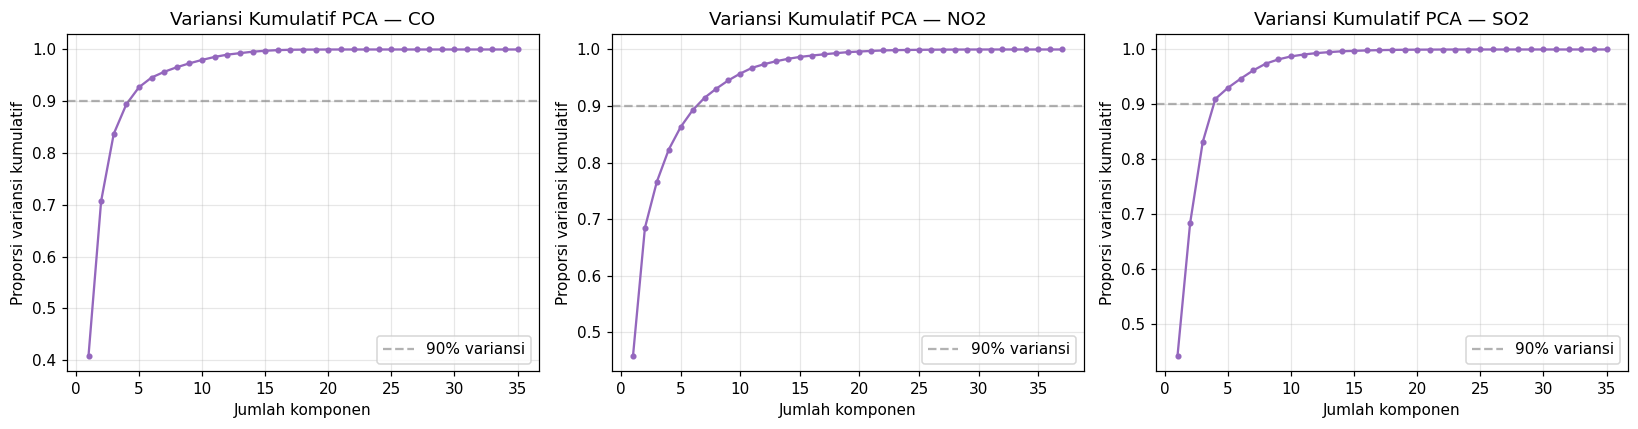

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, d) in zip(axes, processed.items()):
    cum = np.cumsum(d["pca_model"].explained_variance_ratio_)
    ax.plot(range(1, len(cum) + 1), cum, marker=".", color="tab:purple")
    ax.axhline(0.9, color="gray", linestyle="--", alpha=0.6, label="90% variansi")
    ax.set_title(f"Variansi Kumulatif PCA — {name}")
    ax.set_xlabel("Jumlah komponen")
    ax.set_ylabel("Proporsi variansi kumulatif")
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 7. Menentukan Jumlah Cluster Terbaik — Data Hasil PCA (37 komponen)

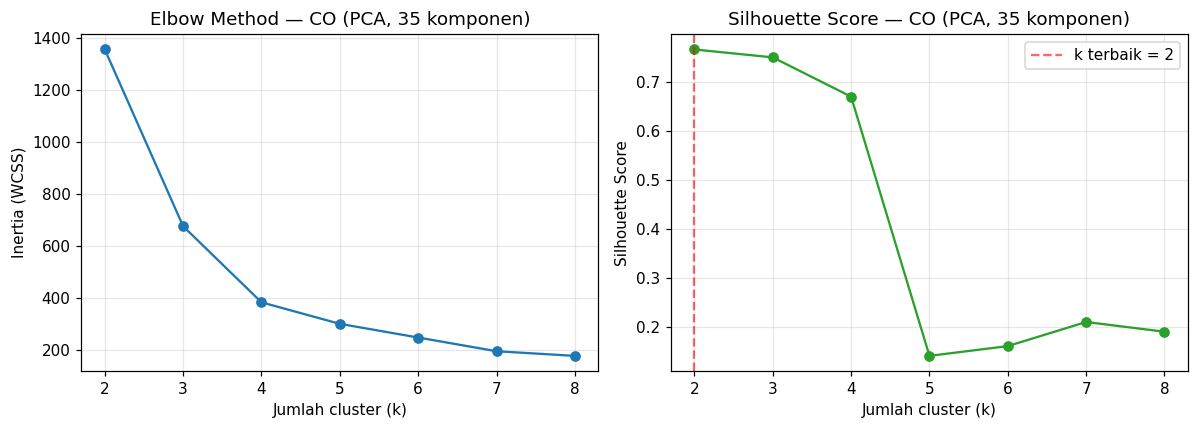

CO: k terbaik = 2  (silhouette = 0.767)



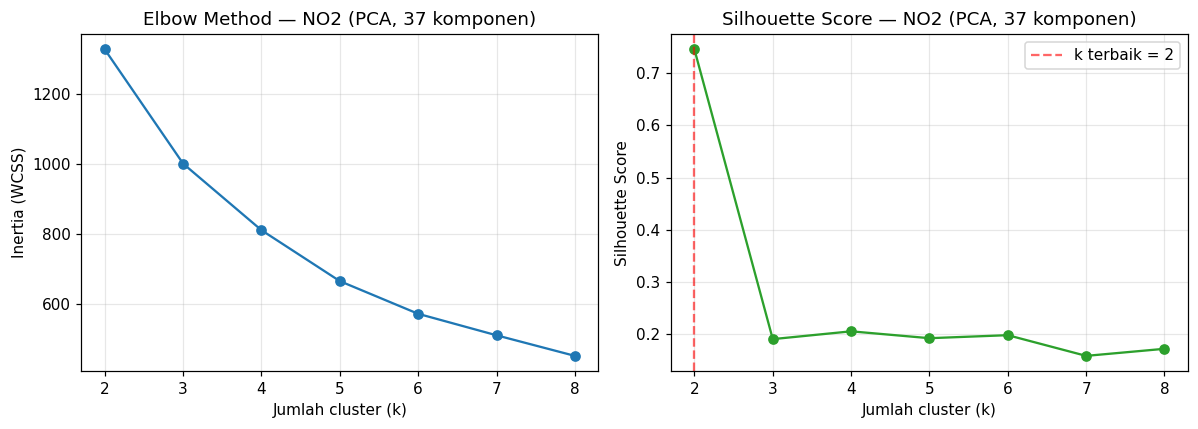

NO2: k terbaik = 2  (silhouette = 0.745)



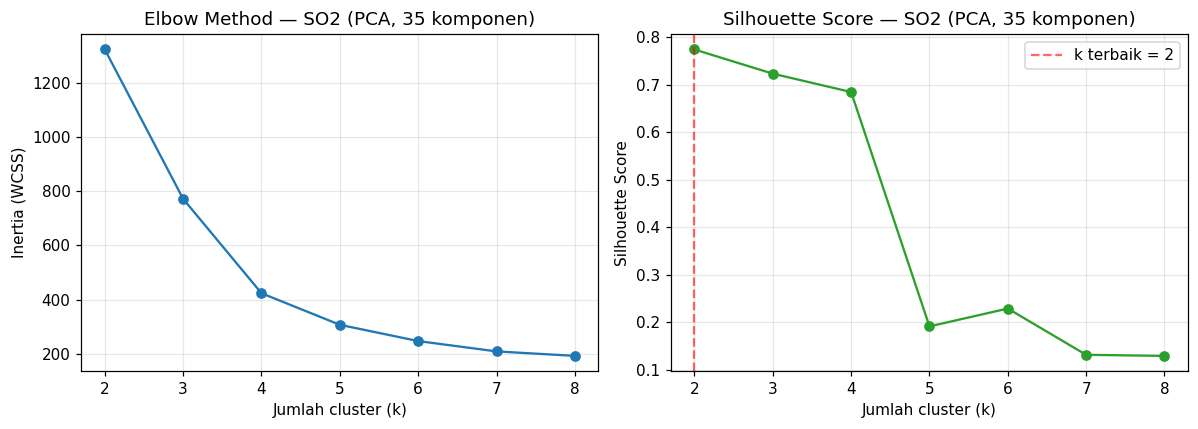

SO2: k terbaik = 2  (silhouette = 0.774)



In [8]:
pca_results = {}
for name, d in processed.items():
    res, k_best, sil_best = evaluate_k_range(d["X_pca"])
    pca_results[name] = (res, k_best, sil_best)
    plot_elbow_silhouette(res, f"{name} (PCA, {d['n_comp_actual']} komponen)")
    print(f"{name}: k terbaik = {k_best}  (silhouette = {sil_best:.3f})\n")


## 8. Menentukan Jumlah Cluster Terbaik — 68 Fitur Asli (Tanpa PCA)

Langkah yang persis sama diulang, kali ini langsung pada data yang sudah distandarisasi **tanpa** reduksi dimensi, sebagai pembanding.

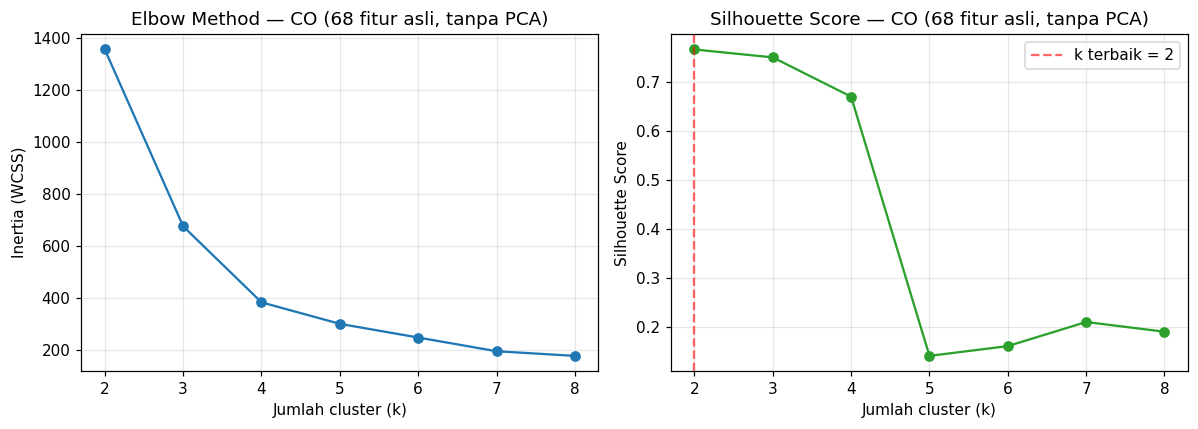

CO: k terbaik = 2  (silhouette = 0.767)



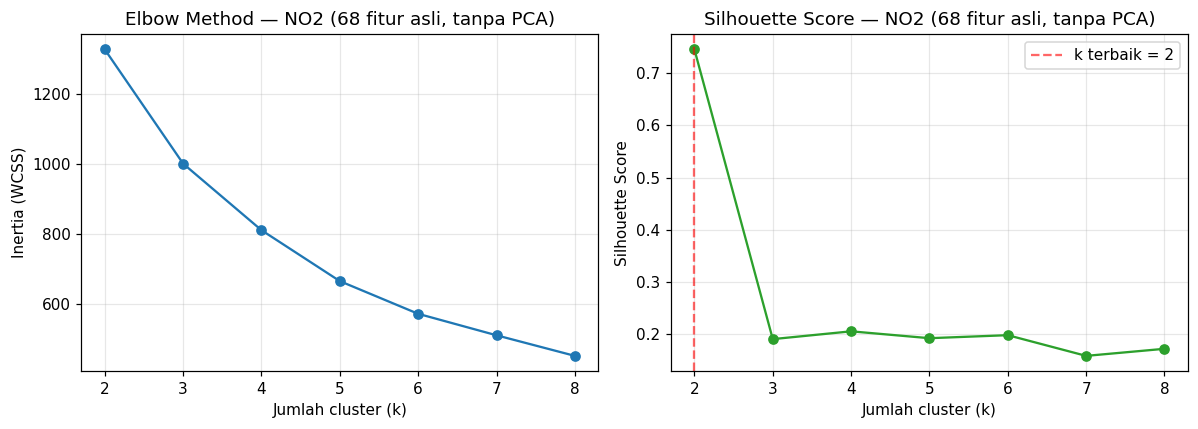

NO2: k terbaik = 2  (silhouette = 0.745)



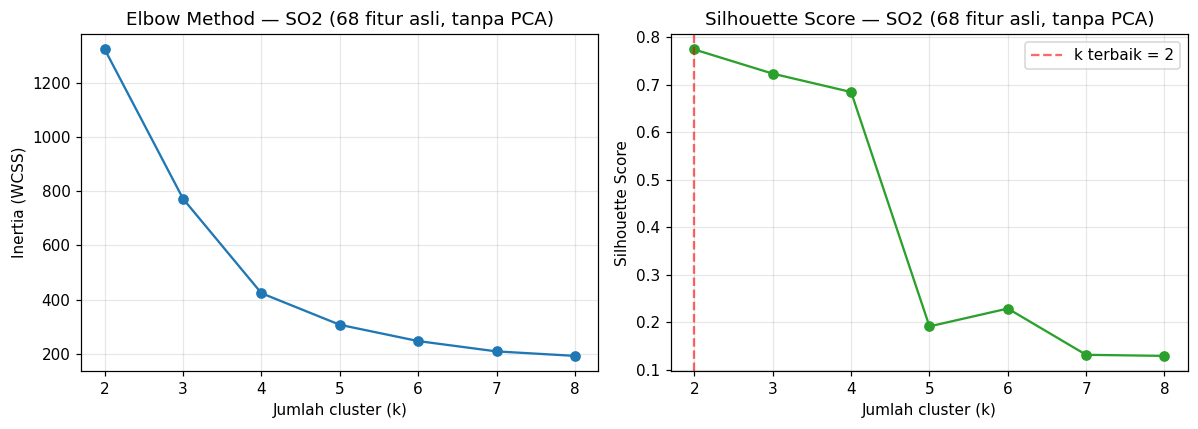

SO2: k terbaik = 2  (silhouette = 0.774)



In [9]:
full_results = {}
for name, d in processed.items():
    res, k_best, sil_best = evaluate_k_range(d["X_scaled"])
    full_results[name] = (res, k_best, sil_best)
    plot_elbow_silhouette(res, f"{name} (68 fitur asli, tanpa PCA)")
    print(f"{name}: k terbaik = {k_best}  (silhouette = {sil_best:.3f})\n")


## 9. Ringkasan & Perbandingan: PCA (37) vs 68 Fitur Asli

In [10]:
summary_rows = []
for name, d in processed.items():
    _, k_pca, sil_pca = pca_results[name]
    _, k_full, sil_full = full_results[name]
    summary_rows.append({
        "Polutan": name,
        "n_sampel": d["X_scaled"].shape[0],
        "n_fitur_dipakai": d["X_scaled"].shape[1],
        "Hopkins": round(d["hopkins"], 3),
        "n_komponen_PCA": d["n_comp_actual"],
        "Var._dijelaskan_PCA (%)": round(d["cum_var"] * 100, 1),
        "k_terbaik (PCA)": k_pca,
        "Silhouette (PCA)": round(sil_pca, 3),
        "k_terbaik (68 fitur)": k_full,
        "Silhouette (68 fitur)": round(sil_full, 3),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df


,Polutan,n_sampel,n_fitur_dipakai,Hopkins,n_komponen_PCA,Var._dijelaskan_PCA (%),k_terbaik (PCA),Silhouette (PCA),k_terbaik (68 fitur),Silhouette (68 fitur)
0,CO,35,65,0.909,35,100.0,2,0.767,2,0.767
1,NO2,37,66,0.818,37,100.0,2,0.745,2,0.745
2,SO2,35,67,0.907,35,100.0,2,0.774,2,0.774


## 10. Interpretasi & Kesimpulan

**Panduan interpretasi Silhouette Score** (Kaufman & Rousseeuw):

| Rentang skor | Interpretasi struktur cluster |
|---|---|
| 0.71 – 1.00 | Struktur kuat (*strong*) |
| 0.51 – 0.70 | Struktur cukup meyakinkan (*reasonable*) |
| 0.26 – 0.50 | Struktur lemah, bisa artifisial (*weak*) |
| ≤ 0.25 | Tidak ada struktur cluster yang berarti |

Isi bagian ini setelah menjalankan seluruh sel di atas, mengacu ke tabel ringkasan pada Bagian 9 dan nilai Hopkins pada Bagian 4, dengan menjawab tiga pertanyaan berikut untuk **setiap polutan**:

1. **Berapa jumlah cluster terbaik?** — lihat kolom `k_terbaik (PCA)` dan `k_terbaik (68 fitur)`. Apakah keduanya konsisten (menghasilkan k yang sama)?
2. **Seberapa baik data ini bisa di-cluster?** — gabungkan nilai `Hopkins` (kecenderungan cluster) dengan nilai `Silhouette` pada k terbaik (kekuatan pemisahan cluster yang terbentuk), lalu cocokkan ke tabel interpretasi di atas.
3. **Apakah reduksi dimensi ke 37 komponen mengubah hasil dibanding 68 fitur asli?** — Perhatikan juga catatan teknis di Bagian 6: untuk dataset dengan jumlah sampel < 37 (CO dan SO2), jumlah komponen PCA otomatis dibatasi sebesar jumlah sampel. Karena itu, komponen PCA yang terbentuk pada kedua dataset ini pada dasarnya adalah **rotasi penuh** dari 68 fitur asli (variansi yang dijelaskan mendekati 100%) — bukan reduksi dimensi yang sesungguhnya menghilangkan informasi. Reduksi dimensi yang benar-benar mengurangi informasi (variansi dijelaskan < 100%) baru relevan dibahas untuk dataset dengan jumlah sampel yang cukup besar (di sini paling mendekati adalah NO2 dengan 37 sampel).
